# Assignment 2: Data Wrangling and Exploratory Analysis

## Task 1: Dataset Selection and Schema Report

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the Titanic passenger dataset (raw, un-cleaned).
df = pd.read_csv("../data/raw/titanic.csv")

# print("Shape (rows, columns):", df.shape)
# print("\nColumn names:")
# print(list(df.columns))
# print("\nDtypes:")
print(df)

     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult_male deck  embark_town alive  alo

In [2]:
# Null counts per column.
print("Null counts:")
print(df.isna().sum())

# Unique-value counts per column.
print("\nUnique value counts:")
print(df.nunique())

Null counts:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Unique value counts:
survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone            2
dtype: int64


**Dataset:** Titanic passenger manifest (891 rows, 15 columns).

**Source:** [seaborn-data / titanic.csv](https://github.com/mwaskom/seaborn-data/blob/master/titanic.csv) — a cleaned re-hosting of the original Kaggle "Titanic: Machine Learning from Disaster" passenger list, distributed with the `seaborn` plotting library.

**License:** The `seaborn-data` repository is released under the BSD-3-Clause license; the underlying passenger data is the long-standing public Titanic dataset used freely for education and competition (Kaggle "Titanic" competition data, public/non-commercial educational use).

**Why I chose it:** It satisfies the size and shape requirements (891 rows, well over 200) and has a natural mix of numeric columns (`age`, `fare`, `sibsp`, `parch`) and categorical columns (`sex`, `embarked`, `class`, `who`, `deck`). It also has real, non-trivial missingness (`age`, `deck`, `embarked`) so the cleaning step in Task 2 is meaningful rather than a formality, and it supports an interesting groupby/pivot question in Task 3: how survival differed by class and sex.

## Task 2: Data Cleaning

In [3]:
# Start from a copy so the raw dataframe stays inspectable above.
df_clean = df.copy()

# `deck` is missing for ~77% of rows (688/891). That is too sparse to impute
# reliably, so we drop the column rather than invent cabin locations.
print("deck null share:", df_clean["deck"].isna().mean().round(3))
df_clean = df_clean.drop(columns=["deck"])

# `alive` is a string duplicate of `survived` (yes/no vs 1/0). Keeping both
# risks the two disagreeing after cleaning, so we drop the redundant column.
assert (df_clean["alive"].map({"yes": 1, "no": 0}) == df_clean["survived"]).all()
df_clean = df_clean.drop(columns=["alive"])

# `embarked`/`embark_town` are missing for only 2 rows. With no reliable way
# to infer a boarding port for so few passengers, we drop those rows instead
# of guessing a port for them.
df_clean = df_clean.dropna(subset=["embarked", "embark_town"])

# `age` is missing for ~20% of rows, too many to drop. We impute with the
# median age *within each class/sex group*, since age varies systematically
# by class and sex (e.g. male crew vs. First-class families), which a single
# global median would ignore.
df_clean["age"] = df_clean.groupby(["pclass", "sex"])["age"].transform(
    lambda group: group.fillna(group.median())
)

print("\nRemaining nulls after cleaning:")
print(df_clean.isna().sum())

deck null share: 0.772

Remaining nulls after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alone          0
dtype: int64


In [4]:
# Dtype fixes: pandas read several genuinely categorical columns as generic
# "object" strings. Casting them to `category` documents intent and saves
# memory; `class` has a natural order so we make it an ordered category.
categorical_cols = ["sex", "embarked", "who", "embark_town"]
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype("category")

df_clean["class"] = pd.Categorical(
    df_clean["class"], categories=["Third", "Second", "First"], ordered=True
)

# `survived` is really a boolean flag, not a free integer.
df_clean["survived"] = df_clean["survived"].astype(bool)

print(df_clean.dtypes)

survived           bool
pclass            int64
sex            category
age             float64
sibsp             int64
parch             int64
fare            float64
embarked       category
class          category
who            category
adult_male         bool
embark_town    category
alone              bool
dtype: object


In [7]:
# Duplicate rows: check across all remaining columns.
duplicate_count = df_clean.duplicated().sum()
print("Duplicate rows found:", duplicate_count)

# 118 rows are exact duplicates of another row. This dataset has no
# passenger-ID or name column, so once the sparse `deck` and redundant
# `alive` columns are dropped, several genuinely different passengers who
# share the same class/sex/age/fare/family-size profile (e.g. multiple solo
# 40-year-old First-class men from Southampton) become indistinguishable.
# These are very unlikely to be true duplicate *records*, just coincidental
# attribute collisions, so we document them but do not drop any rows --
# dropping would silently delete real, distinct passengers.
print("Shape after cleaning:", df_clean.shape)

Duplicate rows found: 118
Shape after cleaning: (889, 13)


## Task 3: Feature Engineering with GroupBy and Merge

In [8]:
# GroupBy aggregation: compute two stats per class (mean fare, mean age),
# then merge them back onto every passenger row. This gives each passenger
# a "class baseline" to compare their own fare/age against, which a raw
# groupby alone (without merging back) can't do per-row.
print("Shape before groupby merge:", df_clean.shape)

class_stats = (
    df_clean.groupby("class", observed=True)
    .agg(class_mean_fare=("fare", "mean"), class_mean_age=("age", "mean"))
    .reset_index()
)
print("\nPer-class stats:")
print(class_stats)

df_clean = df_clean.merge(class_stats, on="class", how="left")
print("\nShape after groupby merge:", df_clean.shape)

Shape before groupby merge: (889, 13)

Per-class stats:
    class  class_mean_fare  class_mean_age
0   Third        13.675550       24.802281
1  Second        20.662183       29.863207
2   First        84.193516       38.160841

Shape after groupby merge: (889, 15)


In [9]:
# Pivot: reshape to answer a specific question -- "did survival depend on
# both class AND sex, not just one or the other?" A single groupby on either
# column alone would hide the interaction between them.
print("Shape before pivot:", df_clean.shape)

survival_pivot = df_clean.pivot_table(
    index="class", columns="sex", values="survived", aggfunc="mean", observed=True
)
print("\nSurvival rate by class and sex:")
print(survival_pivot.round(3))

print("\nShape of pivot result:", survival_pivot.shape)

Shape before pivot: (889, 15)

Survival rate by class and sex:
sex     female   male
class                
Third    0.500  0.135
Second   0.921  0.157
First    0.967  0.369

Shape of pivot result: (3, 2)


## Task 4: NumPy-Based Computation

In [10]:
# Fare is heavily right-skewed (a few very expensive First-class tickets),
# so raw dollar amounts are hard to compare across passengers. Standardizing
# to a z-score (how many standard deviations from the mean) makes fares
# comparable on one scale -- this is awkward to phrase as a single Pandas
# expression but trivial as vectorized NumPy broadcasting.
fare_array = df_clean["fare"].to_numpy()

fare_zscore = (fare_array - fare_array.mean()) / fare_array.std()

print("Mean:", fare_zscore.mean().round(6))
print("Std:", fare_zscore.std().round(3))
print("Min:", fare_zscore.min().round(3))
print("Max:", fare_zscore.max().round(3))

df_clean["fare_zscore"] = fare_zscore

Mean: 0.0
Std: 1.0
Min: -0.646
Max: 9.669


## Task 5: Exploratory Visualization

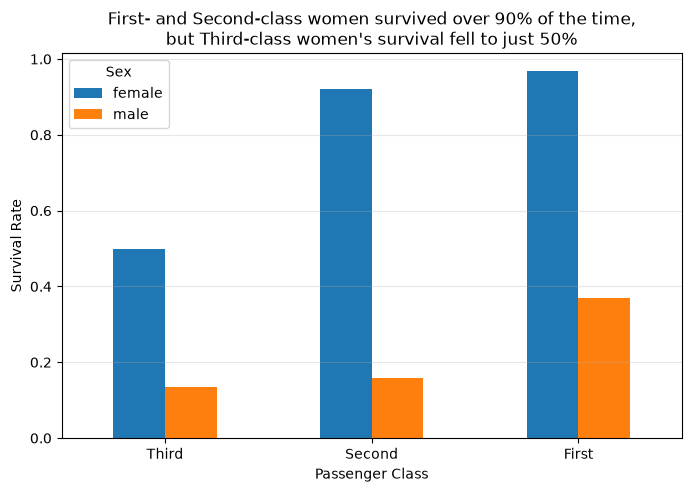

In [11]:
# Chart 1: survival rate by class and sex (grouped bar), from the pivot
# table computed in Task 3.
fig, ax = plt.subplots(figsize=(8, 5))

survival_pivot.plot(kind="bar", ax=ax)

ax.set_xlabel("Passenger Class")
ax.set_ylabel("Survival Rate")
ax.set_title(
    "First- and Second-class women survived over 90% of the time,\n"
    "but Third-class women's survival fell to just 50%"
)
ax.legend(title="Sex")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.savefig("../reports/a2_chart1.png", dpi=150, bbox_inches="tight")
plt.show()

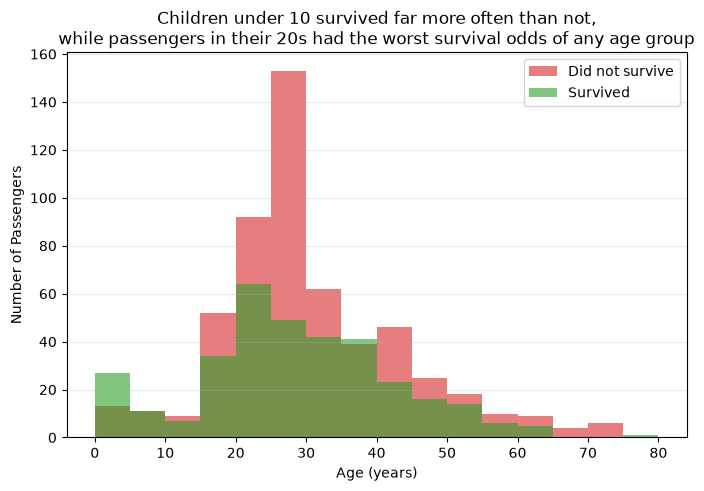

In [12]:
# Chart 2: age distribution split by survival outcome.
fig, ax = plt.subplots(figsize=(8, 5))

bins = range(0, 85, 5)
ax.hist(
    df_clean.loc[~df_clean["survived"], "age"],
    bins=bins, alpha=0.6, label="Did not survive", color="tab:red",
)
ax.hist(
    df_clean.loc[df_clean["survived"], "age"],
    bins=bins, alpha=0.6, label="Survived", color="tab:green",
)

ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of Passengers")
ax.set_title(
    "Children under 10 survived far more often than not,\n"
    "while passengers in their 20s had the worst survival odds of any age group"
)
ax.legend()
plt.grid(axis="y", alpha=0.3)

plt.savefig("../reports/a2_chart2.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 6: Cleaned Dataset and Report

In [15]:
# Save the cleaned, feature-engineered dataset for downstream use.
df_clean.to_csv("../data/processed/titanic_clean.csv", index=False)
print("Saved:", df_clean.shape)



Saved: (889, 16)


## Task 7: Predictive Modeling Logistic Regression vs. Random Forest

**Goal:** predict `survived` from a passenger's `pclass`, `sex`, `age`, and `fare`.

**Why not linear regression?** `survived` is a *binary* label (0 = died, 1 = survived), not a continuous quantity like the car-dataset's `Price`. Linear regression fits a straight line and can output any real number, including things like `-0.3` or `1.8`, which have no meaning for a yes/no outcome. It also assumes the errors are normally distributed and that the effect of each feature on the target is constant and additive on the *raw* scale, assumptions that don't hold for a 0/1 outcome (the relationship between, say, `age` and *probability* of survival is not a straight line it flattens out near 0 and 1).

**Logistic regression** instead fits a straight line in *log-odds* space and squashes the result through a sigmoid function, so its output is always a probability between 0 and 1. Thresholding that probability (commonly at 0.5) gives the class prediction. It's the direct classification analogue of linear regression and a sensible baseline model here.

We'll compare it against a **Random Forest Classifier,** an ensemble of decision trees that makes no assumption about a linear relationship and can capture interactions (e.g. "being female *and* first class" mattering more than either alone) automatically.

In [16]:
# Select the modeling features and target, and prepare them for scikit-learn.
# `sex` is categorical text ("male"/"female"); scikit-learn models require
# numeric input, so we map it to 0/1. This is safe here because `sex` is
# binary -- for a category with 3+ unrelated values we'd use one-hot
# encoding (pd.get_dummies) instead, since integers 0/1/2 would falsely
# imply an order.
feature_cols = ["pclass", "sex", "age", "fare"]

df_model = df_clean[feature_cols + ["survived"]].copy()
df_model["sex"] = df_model["sex"].map({"male": 0, "female": 1})

# Missing values were already handled back in Task 2 (age was imputed,
# rows with missing embarked/embark_town were dropped), so we expect zero
# nulls here -- this just confirms that.
print("Missing values in modeling columns:")
print(df_model.isna().sum())

X = df_model[feature_cols]
y = df_model["survived"].astype(int)

print("\nFeature matrix shape:", X.shape)
print("\nClass balance (0 = did not survive, 1 = survived):")
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))

Missing values in modeling columns:
pclass      0
sex         0
age         0
fare        0
survived    0
dtype: int64

Feature matrix shape: (889, 4)

Class balance (0 = did not survive, 1 = survived):
survived
0    549
1    340
Name: count, dtype: int64
survived
0    0.618
1    0.382
Name: proportion, dtype: float64


In [18]:
# Split into training and testing sets. `stratify=y` keeps the survival
# rate (~38%) roughly equal in both the train and test sets -- without it,
# a random split could by chance put too many/few survivors in the test
# set, making the evaluation metrics misleading for this imbalanced target.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "  Test shape:", X_test.shape)
print("Train survival rate:", y_train.mean().round(3))
print("Test survival rate: ", y_test.mean().round(3))

Train shape: (711, 4)   Test shape: (178, 4)
Train survival rate: 0.383
Test survival rate:  0.382


In [19]:
# Train the Logistic Regression model.
#
# We wrap it in a Pipeline with StandardScaler because Logistic Regression
# is a linear, gradient-based model: its coefficients and solver are
# sensitive to feature scale. `fare` ranges roughly 0-500 while `pclass`
# only ranges 1-3, so without scaling, `fare` would dominate the
# optimization purely because of its larger numbers, not because it's
# more predictive. Scaling (subtracting the mean, dividing by the
# standard deviation) puts every feature on a comparable footing.
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

log_reg = make_pipeline(StandardScaler(), LogisticRegression(random_state=42))
log_reg.fit(X_train, y_train)

log_reg_preds = log_reg.predict(X_test)
print("Logistic Regression trained. First 10 test predictions:", log_reg_preds[:10])

Logistic Regression trained. First 10 test predictions: [0 0 0 0 0 1 0 1 1 0]


In [20]:
# Train the Random Forest Classifier on the *unscaled* features.
#
# Tree-based models split on "is feature > threshold?" one feature at a
# time, so multiplying a feature by a constant doesn't change where the
# best split point falls -- scaling has no effect on a tree's structure.
# That's why we can (and normally do) skip StandardScaler for Random Forest.
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train, y_train)

rf_preds = rf_clf.predict(X_test)
print("Random Forest trained. First 10 test predictions:", rf_preds[:10])

Random Forest trained. First 10 test predictions: [0 0 0 1 0 1 0 1 1 0]


In [21]:
# Evaluate both models on the held-out test set.
#
# - Accuracy: overall fraction of correct predictions. Can be misleading
#   on imbalanced data (e.g. always predicting "died" would score ~62%
#   here without being useful).
# - Precision: of everyone we *predicted* survived, what fraction actually
#   did. High precision = few false alarms.
# - Recall: of everyone who *actually* survived, what fraction we caught.
#   High recall = few missed survivors.
# - F1-score: the harmonic mean of precision and recall -- a single number
#   that penalizes models which trade one off too heavily for the other.
# - Confusion matrix: the raw counts behind all of the above, laid out as
#   [[true negatives, false positives], [false negatives, true positives]].
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)


def evaluate(name, y_true, y_pred):
    print(f"--- {name} ---")
    print("Accuracy: ", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall:   ", round(recall_score(y_true, y_pred), 3))
    print("F1-score: ", round(f1_score(y_true, y_pred), 3))
    print("\nConfusion matrix (rows = actual, cols = predicted):")
    print(confusion_matrix(y_true, y_pred))
    print("\nFull classification report:")
    print(classification_report(y_true, y_pred, target_names=["Did not survive", "Survived"]))
    print()


evaluate("Logistic Regression", y_test, log_reg_preds)
evaluate("Random Forest", y_test, rf_preds)

--- Logistic Regression ---
Accuracy:  0.803
Precision: 0.746
Recall:    0.735
F1-score:  0.741

Confusion matrix (rows = actual, cols = predicted):
[[93 17]
 [18 50]]

Full classification report:
                 precision    recall  f1-score   support

Did not survive       0.84      0.85      0.84       110
       Survived       0.75      0.74      0.74        68

       accuracy                           0.80       178
      macro avg       0.79      0.79      0.79       178
   weighted avg       0.80      0.80      0.80       178


--- Random Forest ---
Accuracy:  0.826
Precision: 0.794
Recall:    0.735
F1-score:  0.763

Confusion matrix (rows = actual, cols = predicted):
[[97 13]
 [18 50]]

Full classification report:
                 precision    recall  f1-score   support

Did not survive       0.84      0.88      0.86       110
       Survived       0.79      0.74      0.76        68

       accuracy                           0.83       178
      macro avg       0.82      0.81

In [22]:
# Look at *why* each model makes its predictions.
#
# Random Forest feature_importances_: how much each feature reduces
# impurity (improves node purity) on average across all trees -- higher
# means the model relied on that feature more.
rf_importances = pd.Series(
    rf_clf.feature_importances_, index=feature_cols
).sort_values(ascending=False)
print("Random Forest feature importances:")
print(rf_importances.round(3))

# Logistic Regression coefficients on the *standardized* features -- since
# every feature is on the same scale, coefficients are directly comparable.
# Sign shows direction (positive = raises survival odds), magnitude shows
# strength.
log_reg_coefs = pd.Series(
    log_reg.named_steps["logisticregression"].coef_[0], index=feature_cols
)
log_reg_coefs = log_reg_coefs.reindex(log_reg_coefs.abs().sort_values(ascending=False).index)
print("\nLogistic Regression coefficients (standardized features):")
print(log_reg_coefs.round(3))

Random Forest feature importances:
fare      0.341
age       0.286
sex       0.283
pclass    0.090
dtype: float64

Logistic Regression coefficients (standardized features):
sex       1.224
pclass   -0.953
age      -0.468
fare      0.042
dtype: float64


## Task 7 Findings: Which Model Predicts More Accurately, and Why

Running the cells above (with `random_state=42` throughout, so results are reproducible) gives:

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | 0.803 | **0.826** |
| Precision | 0.746 | **0.794** |
| Recall | 0.735 | 0.735 |
| F1-score | 0.741 | **0.763** |

**Random Forest predicts more accurately** on this test set it beats Logistic Regression on accuracy, precision, and F1, and ties on recall. Looking at the confusion matrices explains why: both models miss the same 18 survivors (recall is identical), but Random Forest makes 4 fewer false-alarm predictions (13 vs. 17 passengers wrongly predicted to survive) — that's exactly the gap in precision and accuracy.

**Why Random Forest has the edge here:**
- The relationship between the features and survival isn't purely linear. The `fare`/`pclass` feature importances (RF) vs. coefficients (Logistic Regression) tell a consistent story about *which* features matter (`sex` and `pclass`/`fare` dominate, `age` matters somewhat, in both models) but Random Forest can also model **interactions**, e.g. a young child's survival advantage or the compounding effect of "female *and* first class," without those interactions being hand-engineered as extra columns. Logistic Regression only sees a straight, additive combination of the four raw features.
- Random Forest doesn't assume a linear log-odds relationship, so it can flexibly bend around ranges where survival probability changes non-uniformly (e.g. a sharp survival advantage for the youngest children isn't a straight line against `age`).

**Why the gap is modest, not huge:**
- With only 4 features and ~900 rows, there isn't a lot of complex signal for Random Forest to exploit that a well-specified linear model can't already approximate `sex` and `pclass` are strong, nearly-linear predictors of survival on their own, which is why Logistic Regression already gets respectably close.
- Random Forest's advantage typically grows with more features, more data, and messier non-linear relationships; on a small, well-understood feature set like this one, a simple linear model remains a solid, more interpretable baseline.

**Practical takeaway:** if the priority is raw predictive performance, Random Forest wins here. If the priority is interpretability (e.g. explaining exactly how much each factor shifts survival odds, as the coefficient table above does directly), Logistic Regression's small accuracy cost may be worth its transparency.